# U-Net (Bleeding)

In [ ]:
# =========================
# 1) Chequeo GPU
# =========================
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings



In [ ]:
# =========================
# 3) Montar Drive (para leer dataset o guardar modelo)
# =========================
from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT_KAGGLE = '/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset'

DATASET_ROOT = DATASET_ROOT_KAGGLE
print("DATASET_ROOT =", DATASET_ROOT)

MODEL_OUT_PATH = '/content/drive/MyDrive/_tp_models/best_unet_bleeding.keras'
import os
os.makedirs(os.path.dirname(MODEL_OUT_PATH), exist_ok=True)
print("MODEL_OUT_PATH =", MODEL_OUT_PATH)


DATASET_ROOT = /kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset
MODEL_OUT_PATH = /kaggle/working/_tp_models/best_unet_ischemic.keras


In [ ]:
# =========================
# 4) Imports
# =========================
!pip -q install scikit-image opencv-python pandas

import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


2026-02-23 10:14:24.917830: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771841665.122419      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771841665.174004      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771841665.619104      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771841665.619141      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771841665.619144      55 computation_placer.cc:177] computation placer alr

In [ ]:
# =========================
# 5) Parámetros
# =========================
IMG_SIZE = 384
BATCH = 32
EPOCHS = 50

#N_PER_CLASS = 1000
CLASSES = ['Ischemia'] #'Bleeding','Ischemia','Normal'

# ---- Loss weighting (opción 1: BCE + Dice ponderado)
W_BCE  = 0.60
W_DICE = 0.40

# ---- Umbral para binarizar en inferencia (para debug)
PRED_THR = 0.75


In [ ]:
# =========================
# 6) Pares (img_path, overlay_path)
# =========================
def list_first_n_pngs(folder,n=1000):
    files = sorted(glob.glob(os.path.join(folder, '*.png')))
    return files[:n]

def list_first_pngs(folder):
    files = sorted(glob.glob(os.path.join(folder, '*.png')))
    return files


TRAIN_POS_CLASS = 'Ischemia'
NEG_CLASS = 'Normal'
N_NEG = 600

pairs = []

# positivos
for ip in list_first_pngs(os.path.join(DATASET_ROOT, TRAIN_POS_CLASS, 'PNG')):
    fn = os.path.basename(ip)
    op = os.path.join(DATASET_ROOT, TRAIN_POS_CLASS, 'OVERLAY', fn)
    pairs.append((ip, op, TRAIN_POS_CLASS))

# negativos: overlay inexistente => mask=0
for ip in list_first_n_pngs(os.path.join(DATASET_ROOT, NEG_CLASS, 'PNG'), N_NEG):
    pairs.append((ip, "", NEG_CLASS))

print("Total pares:", len(pairs))


Total pares: 1730


In [ ]:
# =========================
# 7) Split train/val (85/15)
# =========================
random.shuffle(pairs)
val_frac = 0.15
n_val = int(len(pairs) * val_frac)

val_pairs = pairs[:n_val]
train_pairs = pairs[n_val:]

print("Train:", len(train_pairs), "Val:", len(val_pairs))


Train: 1471 Val: 259


In [ ]:
# =========================
# 8) TF Dataset: imagen + máscara (GT desde OVERLAY rojo en HSV)
# =========================
def decode_png_grayscale(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method='bilinear')
    return img

def overlay_to_mask(overlay_rgb):
    hsv = tf.image.rgb_to_hsv(overlay_rgb)
    h = hsv[..., 0]
    s = hsv[..., 1]
    v = hsv[..., 2]

    red1 = (h <= (10.0/360.0))
    red2 = (h >= (170.0/360.0))
    red = tf.logical_or(red1, red2)
    red = tf.logical_and(red, s >= 0.2)
    red = tf.logical_and(red, v >= 0.2)

    mask = tf.cast(red, tf.float32)[..., tf.newaxis]
    return mask

def decode_overlay_mask(path):
    def _no_overlay():
        return tf.zeros((IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32), tf.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32)

    def _with_overlay():
        ovl_rgb = tf.io.read_file(path)
        ovl_rgb = tf.image.decode_png(ovl_rgb, channels=3)
        ovl_rgb = tf.image.convert_image_dtype(ovl_rgb, tf.float32)
        ovl_rgb = tf.image.resize(ovl_rgb, (IMG_SIZE, IMG_SIZE), method='nearest')
        mask = overlay_to_mask(ovl_rgb)
        return mask, ovl_rgb

    return tf.cond(tf.equal(tf.strings.length(path), 0), _no_overlay, _with_overlay)

def parse_example(img_path, ovl_path):
    img = decode_png_grayscale(img_path)
    mask, overlay_rgb_display = decode_overlay_mask(ovl_path)
    return img, mask, overlay_rgb_display

import tensorflow as tf

def random_gamma(img, gamma_range=(0.9, 1.1)):
    g = tf.random.uniform([], gamma_range[0], gamma_range[1])
    img = tf.clip_by_value(img, 0.0, 1.0)
    return tf.pow(img, g)

def random_noise(img, sigma_range=(0.0, 0.03)):
    s = tf.random.uniform([], sigma_range[0], sigma_range[1])
    noise = tf.random.normal(tf.shape(img), mean=0.0, stddev=s)
    return tf.clip_by_value(img + noise, 0.0, 1.0)

import tensorflow as tf

def gaussian_noise(img, sigma_range=(0.0, 0.03)):
    sigma = tf.random.uniform([], sigma_range[0], sigma_range[1])
    noise = tf.random.normal(tf.shape(img), mean=0.0, stddev=sigma, dtype=img.dtype)
    return img + noise

def aug(img, mask, overlay_rgb_display):
    if tf.random.uniform(()) < 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
        overlay_rgb_display = tf.image.flip_left_right(overlay_rgb_display)

    if tf.random.uniform(()) < 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
        overlay_rgb_display = tf.image.flip_up_down(overlay_rgb_display)

    if tf.random.uniform(()) < 0.5:
        k = tf.random.uniform([], 0, 4, dtype=tf.int32)
        img  = tf.image.rot90(img, k)
        mask = tf.image.rot90(mask, k)
        overlay_rgb_display = tf.image.rot90(overlay_rgb_display, k)

    return img, mask, overlay_rgb_display

def make_ds(pairs_list, training=False):
    img_paths = [p[0] for p in pairs_list]
    ovl_paths = [p[1] for p in pairs_list]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, ovl_paths))
    if training:
        ds = ds.shuffle(buffer_size=min(len(pairs_list), 2000), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(parse_example, num_parallel_calls=AUTOTUNE)

    if training:
      ds = ds.map(aug, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_pairs, training=True)
val_ds = make_ds(val_pairs, training=False)


x, y, z = next(iter(train_ds))
print("Batch x:", x.shape, "Batch y:", y.shape, "Batch z (overlay):", z.shape, "mask mean:", float(tf.reduce_mean(y)))


I0000 00:00:1771841690.378861      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771841690.381689      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Batch x: (32, 384, 384, 1) Batch y: (32, 384, 384, 1) Batch z (overlay): (32, 384, 384, 3) mask mean: 0.011900371871888638


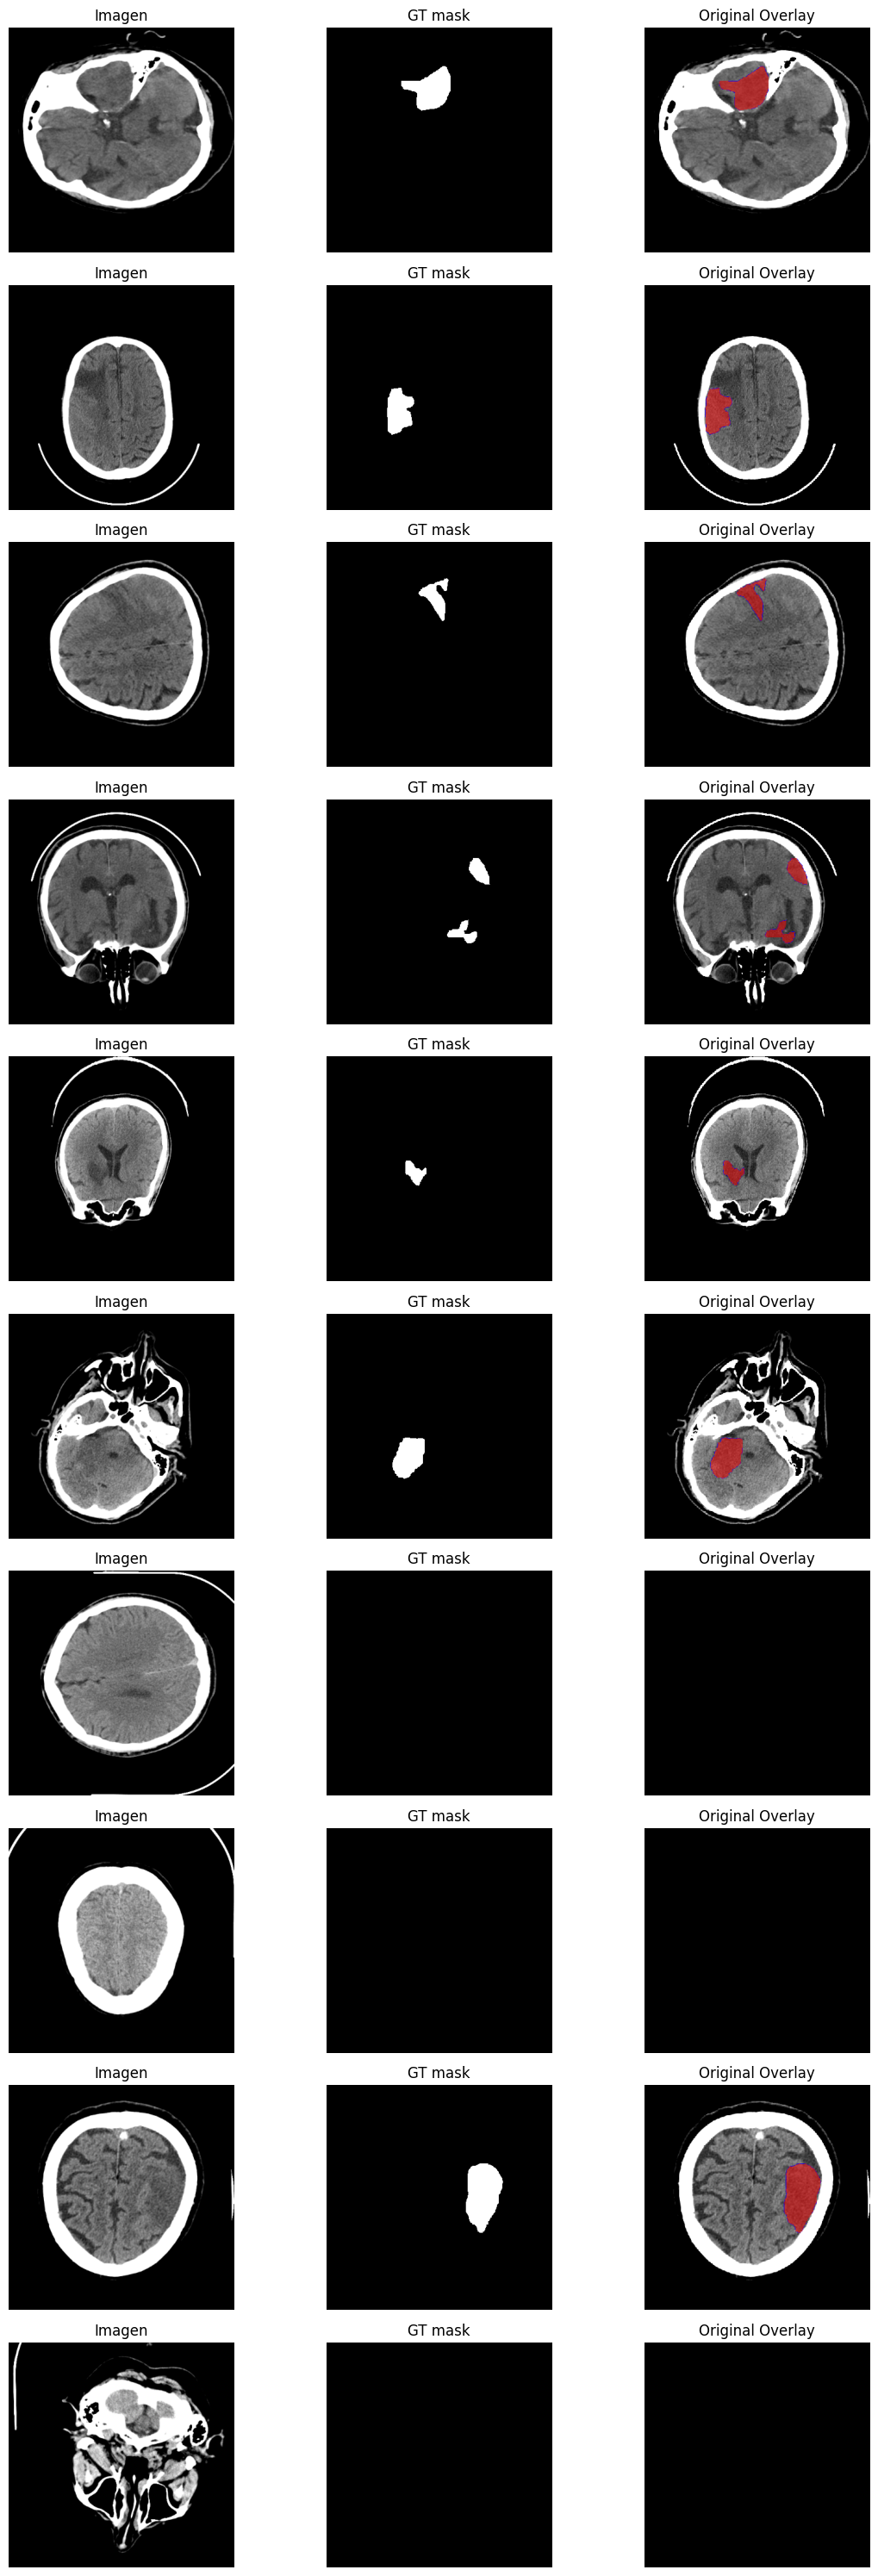

In [ ]:
# =========================
# 9) Debug visual
# =========================
def show_batch(ds, n=4):
    x, y, z = next(iter(ds))
    n = min(n, x.shape[0])
    plt.figure(figsize=(12, 3*n))
    for i in range(n):
        plt.subplot(n, 3, 3*i+1)
        plt.imshow(x[i,...,0], cmap='gray'); plt.title('Imagen'); plt.axis('off')
        plt.subplot(n, 3, 3*i+2)
        plt.imshow(y[i,...,0], cmap='gray'); plt.title('GT mask'); plt.axis('off')
        plt.subplot(n, 3, 3*i+3)
        plt.imshow(z[i,...]); plt.title('Original Overlay'); plt.axis('off')
    plt.tight_layout(); plt.show()

show_batch(train_ds, n=10)


In [ ]:
# =========================
# 10) U-Net + loss BCE+Dice
# =========================
from tensorflow.keras import layers, models

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 1), base=32):
    inputs = layers.Input(shape=input_shape)

    c1 = conv_block(inputs, base);     p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, base*2);       p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, base*4);       p3 = layers.MaxPooling2D()(c3)
    c4 = conv_block(p3, base*8);       p4 = layers.MaxPooling2D()(c4)

    bn = conv_block(p4, base*16)

    u4 = layers.UpSampling2D()(bn); u4 = layers.Concatenate()([u4, c4]); c5 = conv_block(u4, base*8)
    u3 = layers.UpSampling2D()(c5); u3 = layers.Concatenate()([u3, c3]); c6 = conv_block(u3, base*4)
    u2 = layers.UpSampling2D()(c6); u2 = layers.Concatenate()([u2, c2]); c7 = conv_block(u2, base*2)
    u1 = layers.UpSampling2D()(c7); u1 = layers.Concatenate()([u1, c1]); c8 = conv_block(u1, base)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c8)
    return models.Model(inputs, outputs)

import tensorflow as tf

def dice_coef(y_true, y_pred, eps=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)
    num = 2.0 * tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    den = tf.reduce_sum(y_true + y_pred, axis=[1,2,3]) + eps
    return tf.reduce_mean(num / den)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

bce = tf.keras.losses.BinaryCrossentropy()

def bce_dice_weighted_loss(y_true, y_pred):
    return W_BCE * bce(y_true, y_pred) + W_DICE * dice_loss(y_true, y_pred)

def iou_coef(y_true, y_pred, eps=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1,2,3]) - inter
    return tf.reduce_mean((inter + eps) / (union + eps))

model = build_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=bce_dice_weighted_loss,
    metrics=[dice_coef, iou_coef]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 384, 384,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 384, 384,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 384, 384,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 384, 384,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 384, 384,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 384, 384,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 192, 192,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 192, 192,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 192,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 192, 192,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 192, 192,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 192,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 192, 192,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 96, 96,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 96, 96,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        512 │ conv2d_4[0][0]  

 Total params: 7,857,857 (29.98 MB)

 Trainable params: 7,851,969 (29.95 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [ ]:
# =========================
# 11) Callbacks: guardar mejor modelo
# =========================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_OUT_PATH,
        monitor='val_dice_coef',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef',
        mode='max',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coef',
        mode='max',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]
print("Guardará el mejor modelo en:", MODEL_OUT_PATH)


Guardará el mejor modelo en: /kaggle/working/_tp_models/best_unet_ischemic.keras


In [ ]:
# =========================
# 12) Entrenamiento
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/50


I0000 00:00:1771841708.160670     129 service.cc:152] XLA service 0x7a2d74040380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771841708.160710     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771841708.160715     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771841710.432480     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-23 10:15:38.950866: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=1,k3=0} for conv %cudnn-conv-bias-activation.73 = (f32[32,32,384,384]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,96,384,384]{3,2,1,0} %bitcast.23494, f32[32,96,3,3]{3,2,1,0} %bitcast.17068, f32[32]{0} %bitcast.23554), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1/conv2d_16_1/convolution"

45/46 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - dice_coef: 0.0394 - iou_coef: 0.0484 - loss: 0.0709

2026-02-23 10:18:36.055635: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 10:18:36.364874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 10:18:48.646054: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=1,k3=0} for conv %cudnn-conv-bias-activation.73 = (f32[31,32,384,384]{3,2,1,0}, u8[0]{0}) custom-call(f32[31,96,384,384]{3,2,1,0} %bitcast.23494, f32[32,96,3,3]{3,2,1,0} %bitcast.17068, f32[32]{0} %bitcast.23554), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1/conv2d_16_1/convolution" source_file=

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - dice_coef: 0.0395 - iou_coef: 0.0498 - loss: 0.0706

2026-02-23 10:20:39.495634: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 10:20:39.767832: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_dice_coef improved from -inf to 0.02575, saving model to /kaggle/working/_tp_models/best_unet_ischemic.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 346s 5s/step - dice_coef: 0.0396 - iou_coef: 0.0511 - loss: 0.0704 - val_dice_coef: 0.0257 - val_iou_coef: 0.0156 - val_loss: 0.1380 - learning_rate: 0.0010
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.0609 - iou_coef: 0.2016 - loss: 0.0510
Epoch 2: val_dice_coef improved from 0.02575 to 0.03150, saving model to /kaggle/working/_tp_models/best_unet_ischemic.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - dice_coef: 0.0610 - iou_coef: 0.2018 - loss: 0.0510 - val_dice_coef: 0.0315 - val_iou_coef: 0.0642 - val_loss: 0.0791 - learning_rate: 0.0010
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_coef: 0.0843 - iou_coef: 0.2198 - loss: 0.0477
Epoch 3: val_dice_coef improved from 0.03150 to 0.03355, saving model to /kaggle/working/_tp_models/best_unet_ischemic.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - dice_coef: 0.

In [ ]:
'''MODEL_PATH = "/kaggle/working/best_unet.keras"
model.save(MODEL_PATH)
print("Guardado en:", MODEL_PATH)'''

Guardado en: /kaggle/working/best_unet.keras


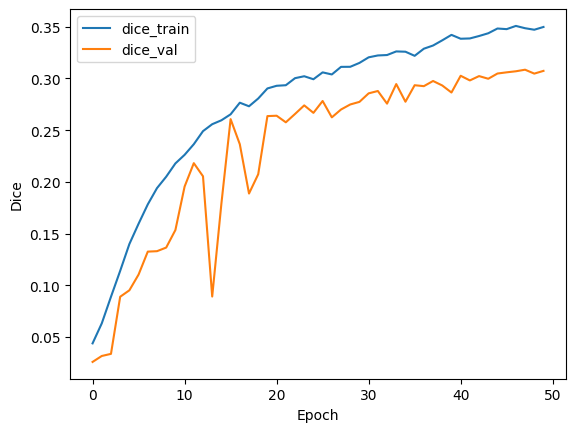

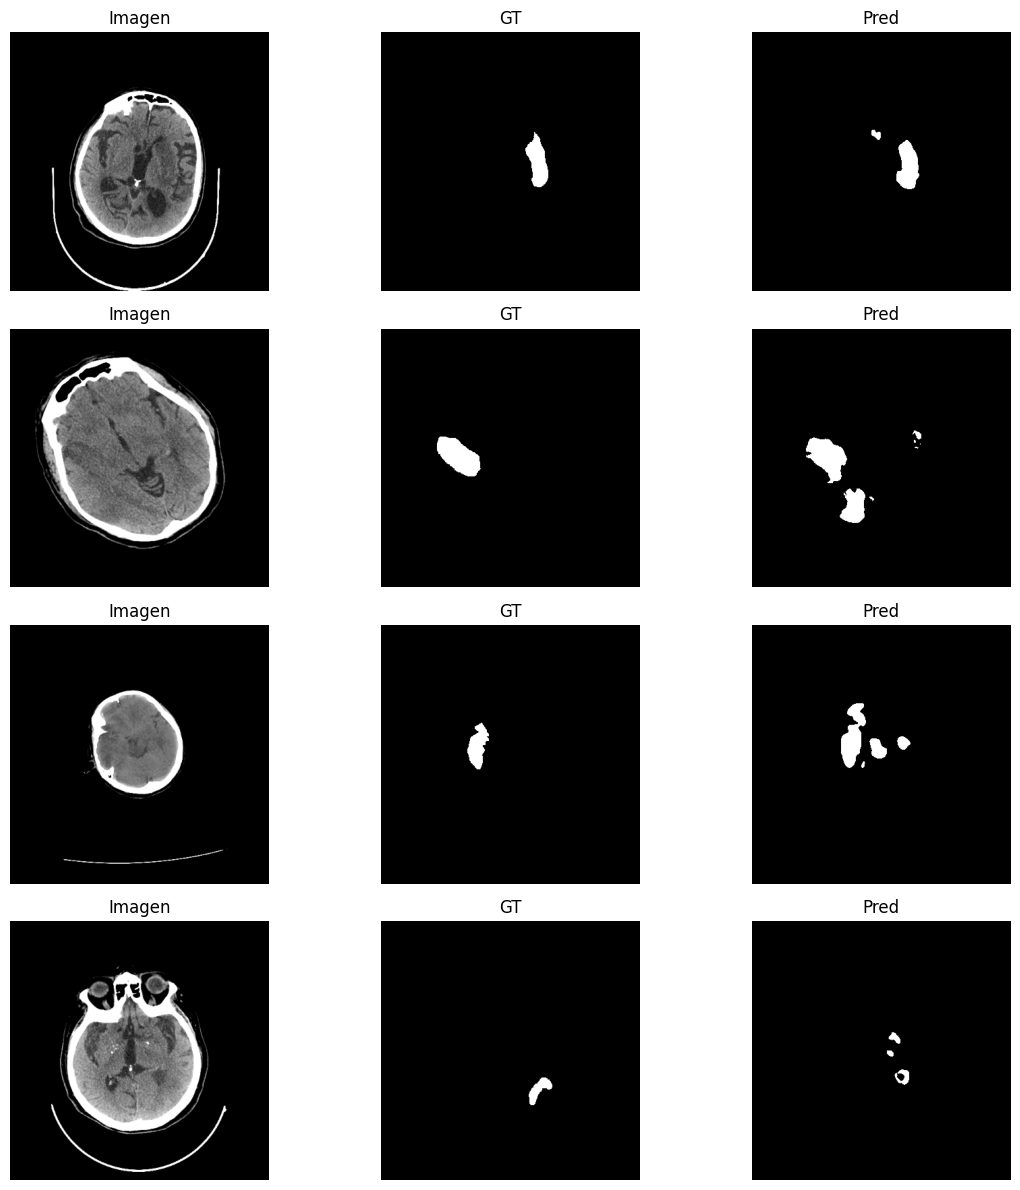

Modelo guardado en: /kaggle/working/_tp_models/best_unet_ischemic.keras


In [ ]:
# =========================
# 13) Curvas + inferencia
# =========================
plt.figure()
plt.plot(history.history['dice_coef'], label='dice_train')
plt.plot(history.history['val_dice_coef'], label='dice_val')
plt.xlabel('Epoch'); plt.ylabel('Dice'); plt.legend(); plt.show()

best_model = tf.keras.models.load_model(
    MODEL_OUT_PATH,
    custom_objects={'bce_dice_weighted_loss': bce_dice_weighted_loss, 'dice_coef': dice_coef, 'dice_loss': dice_loss, 'iou_coef': iou_coef}
)

x, y, z = next(iter(val_ds))
pred = best_model.predict(x, verbose=0)
pred_bin = (pred > PRED_THR).astype(np.float32)

n = min(4, x.shape[0])
plt.figure(figsize=(12, 3*n))
for i in range(n):
    plt.subplot(n, 3, 3*i+1); plt.imshow(x[i,...,0], cmap='gray'); plt.title('Imagen'); plt.axis('off')
    plt.subplot(n, 3, 3*i+2); plt.imshow(y[i,...,0], cmap='gray'); plt.title('GT'); plt.axis('off')
    plt.subplot(n, 3, 3*i+3); plt.imshow(pred_bin[i,...,0], cmap='gray'); plt.title('Pred'); plt.axis('off')
plt.tight_layout(); plt.show()

print("Modelo guardado en:", MODEL_OUT_PATH)
